In [1]:
import pandas as pd
df = pd.read_excel("/content/uae_rental_dataset.xlsx")
df.head(10)

,Address,Rent,Beds,Baths,Type,Area_in_sqft,Rent_per_sqft,Rent_category,Frequency,Furnishing,Purpose,Posted_date,Age_of_listing_in_days,Location,City,Latitude,Longitude
0,"The Gate Tower 2, The Gate Tower, Shams Gate D...",124000,3,4,Apartment,1785,69.467787,Medium,Yearly,Unfurnished,For Rent,2024-03-07,45,Al Reem Island,Abu Dhabi,24.493598,54.407841
1,"Water's Edge, Yas Island, Abu Dhabi",140000,3,4,Apartment,1422,98.452883,Medium,Yearly,Unfurnished,For Rent,2024-03-08,44,Yas Island,Abu Dhabi,24.494022,54.607372
2,"Al Raha Lofts, Al Raha Beach, Abu Dhabi",99000,2,3,Apartment,1314,75.342466,Medium,Yearly,Furnished,For Rent,2024-03-21,31,Al Raha Beach,Abu Dhabi,24.485931,54.600939
3,"Marina Heights, Marina Square, Al Reem Island,...",220000,3,4,Penthouse,3843,57.246942,High,Yearly,Unfurnished,For Rent,2024-02-24,57,Al Reem Island,Abu Dhabi,24.493598,54.407841
4,"West Yas, Yas Island, Abu Dhabi",350000,5,7,Villa,6860,51.020408,High,Yearly,Unfurnished,For Rent,2024-02-16,65,Yas Island,Abu Dhabi,24.494022,54.607372
5,"Reflection, Shams Abu Dhabi, Al Reem Island, A...",75000,1,1,Apartment,706,106.232295,Medium,Yearly,Furnished,For Rent,2023-12-12,131,Al Reem Island,Abu Dhabi,24.493598,54.407841
6,"Water's Edge, Yas Island, Abu Dhabi",65000,1,1,Apartment,698,93.123209,Low,Yearly,Unfurnished,For Rent,2024-03-11,41,Yas Island,Abu Dhabi,24.494022,54.607372
7,"Noya, Yas Island, Abu Dhabi",170000,3,4,Townhouse,1989,85.470085,High,Yearly,Unfurnished,For Rent,2024-02-22,59,Yas Island,Abu Dhabi,24.494022,54.607372
8,"Ansam 3, Ansam, Yas Island, Abu Dhabi",75000,1,2,Apartment,886,84.650113,Medium,Yearly,Unfurnished,For Rent,2024-04-05,16,Yas Island,Abu Dhabi,24.494022,54.607372
9,"Marina Heights I, Marina Heights, Marina Squar...",160000,2,3,Apartment,1430,111.888112,High,Yearly,Unfurnished,For Rent,2024-04-05,16,Al Reem Island,Abu Dhabi,24.493598,54.407841


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73742 entries, 0 to 73741
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Address                 73742 non-null  object        
 1   Rent                    73742 non-null  int64         
 2   Beds                    73742 non-null  int64         
 3   Baths                   73742 non-null  int64         
 4   Type                    73742 non-null  object        
 5   Area_in_sqft            73742 non-null  int64         
 6   Rent_per_sqft           73742 non-null  float64       
 7   Rent_category           73742 non-null  object        
 8   Frequency               73742 non-null  object        
 9   Furnishing              73742 non-null  object        
 10  Purpose                 73742 non-null  object        
 11  Posted_date             73742 non-null  datetime64[ns]
 12  Age_of_listing_in_days  73742 non-null  int64 

At a quick glance, there are null values in Latitude and Longitude columns.

In [3]:
df.describe()

,Rent,Beds,Baths,Area_in_sqft,Rent_per_sqft,Posted_date,Age_of_listing_in_days,Latitude,Longitude
count,7.374200e+04,73742.000000,73742.000000,73742.000000,73742.000000,73742,73742.000000,73023.000000,73023.000000
mean,1.479250e+05,2.162811,2.650213,2054.053552,88.057754,2024-02-06 17:43:22.337880576,74.261547,24.918929,55.053133
min,0.000000e+00,0.000000,1.000000,74.000000,0.000000,2018-01-27 00:00:00,11.000000,15.175847,43.351928
25%,5.499900e+04,1.000000,2.000000,850.000000,39.977778,2024-01-17 00:00:00,30.000000,24.493598,54.607372
50%,9.800000e+04,2.000000,2.000000,1334.000000,71.428571,2024-02-29 00:00:00,52.000000,25.078641,55.238209
75%,1.700000e+05,3.000000,3.000000,2130.000000,118.483412,2024-03-22 00:00:00,95.000000,25.197978,55.367138
max,5.500000e+07,12.000000,11.000000,210254.000000,2182.044888,2024-04-10 00:00:00,2276.000000,25.920310,56.361294
std,3.069658e+05,1.578155,1.632997,3003.919252,66.534400,NaN,72.346767,0.569356,0.653722


1. Min value in rent shows 0 AED (might be invalid)

In [4]:
df.isnull().sum()

,0
Address,0
Rent,0
Beds,0
Baths,0
Type,0
Area_in_sqft,0
Rent_per_sqft,0
Rent_category,0
Frequency,0
Furnishing,0


In [5]:
# Handling missing latitude and longitude values
df["Latitude"] = df.groupby("City")["Latitude"].transform(lambda x: x.fillna(x.median))
df["Longitude"] = df.groupby("City")["Longitude"].transform(lambda x: x.fillna(x.median))

df[["Latitude","Longitude"]].isnull().sum()

,0
Latitude,0
Longitude,0


In [6]:
df.duplicated().sum()

np.int64(0)

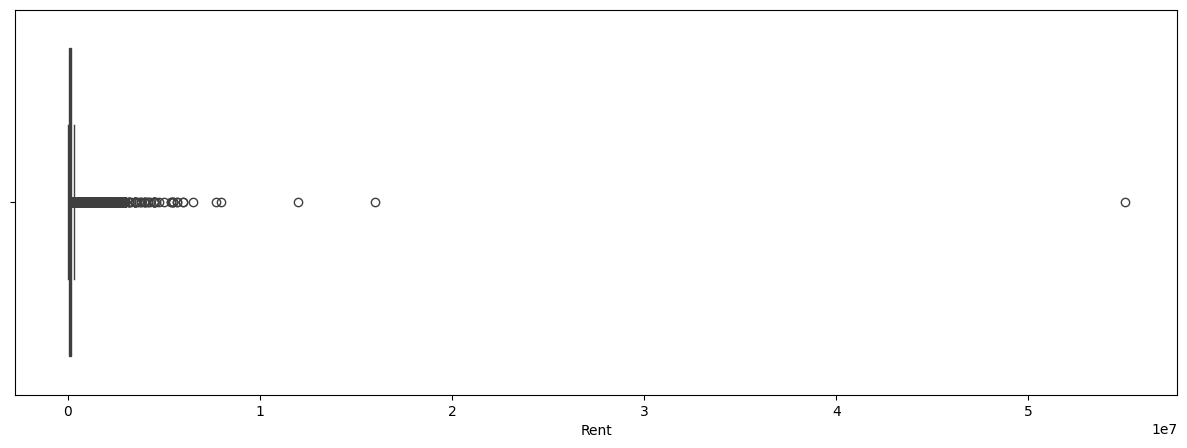

In [7]:
# detect extreme outliers
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
sns.boxplot(x=df["Rent"])
plt.show()

In [8]:
# Running describe on rent column to see max value
df["Rent"].describe()

,Rent
count,7.374200e+04
mean,1.479250e+05
std,3.069658e+05
min,0.000000e+00
25%,5.499900e+04
50%,9.800000e+04
75%,1.700000e+05
max,5.500000e+07


In [9]:
# describe() showed Minimum rent as 0 which I will remove
df = df[df["Rent"] > 0]

In [10]:
# rechecking
df["Rent"].describe()

,Rent
count,7.372700e+04
mean,1.479551e+05
std,3.069898e+05
min,1.000000e+00
25%,5.499900e+04
50%,9.800000e+04
75%,1.700000e+05
max,5.500000e+07


In [11]:
df.isnull().sum()

,0
Address,0
Rent,0
Beds,0
Baths,0
Type,0
Area_in_sqft,0
Rent_per_sqft,0
Rent_category,0
Frequency,0
Furnishing,0


In [12]:
df.duplicated().sum()

np.int64(0)

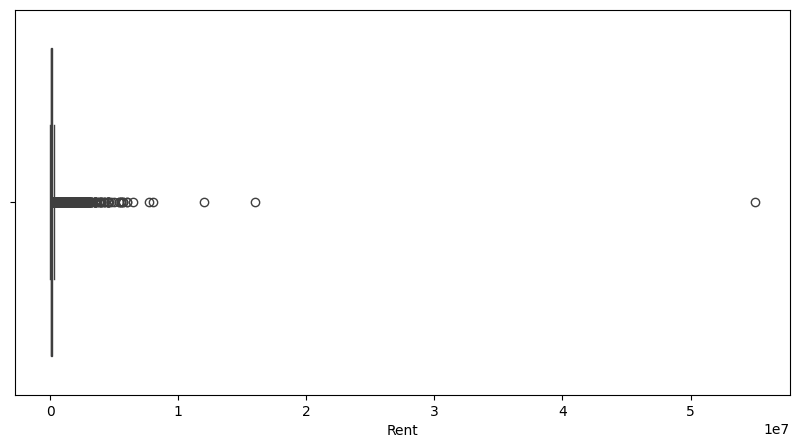

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x=df["Rent"])
plt.show()

In [14]:
#running this to see how many listings might fall under 'ultra luxury'
df[df["Rent"] > 10000000].head()

,Address,Rent,Beds,Baths,Type,Area_in_sqft,Rent_per_sqft,Rent_category,Frequency,Furnishing,Purpose,Posted_date,Age_of_listing_in_days,Location,City,Latitude,Longitude
31677,"Signature Villas Frond H, Signature Villas Pal...",16000000,10,2,Villa,23745,673.826069,High,Yearly,Furnished,For Rent,2024-02-20,61,Palm Jumeirah,Dubai,25.118088,55.134201
55471,"Frond J, Palm Jumeirah, Dubai",12000000,10,2,Villa,30776,389.914219,High,Yearly,Furnished,For Rent,2024-01-25,87,Palm Jumeirah,Dubai,25.118088,55.134201
56785,"Dubai Investment Park 1, Dubai Investment Park...",55000000,11,2,Residential Building,129576,424.461320,High,Yearly,Unfurnished,For Rent,2024-03-30,22,Dubai Investment Park (DIP),Dubai,24.985928,55.175013


This step showed that there is just three listings with a rent above the rent of AED 10,000,000. I will carry out Log Transformation as a new column without replacing the original rent column. This will help compress extreme values, make visualization clearer and we're not losing data.

In [15]:
import numpy as np
df["Log_Rent"] = np.log1p(df["Rent"])

<Axes: xlabel='Log_Rent'>

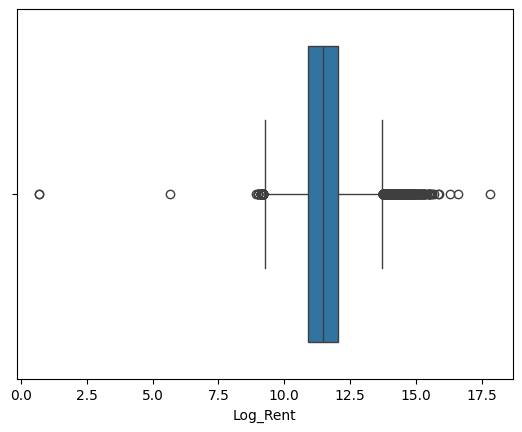

In [16]:
sns.boxplot(x=df["Log_Rent"])

Feature Engineering

In [17]:
#Feature 1
df["Rent_per_bedroom"] = df["Rent"] / df["Beds"].replace(0,np.nan)

In [18]:
#Feature 2 - Price Density
df["Price_Density"] = df["Rent"] / df ["Area_in_sqft"]

In [19]:
#Feature 3 - Luxury
df["Luxury"] = df ["Rent"] > 500000

In [20]:
#Average rent by city :
df.groupby("City")["Rent"].mean().sort_values(ascending=False)

,Rent
City,
Dubai,213453.612542
Abu Dhabi,115261.981693
Ras Al Khaimah,77539.276961
Fujairah,73592.555556
Ajman,68247.255102
Al Ain,64640.382692
Sharjah,47888.281450
Umm Al Quwain,45230.769231


In [21]:
# Feature 4
df["Market_Tier"] = df["City"].map({
    "Dubai":"Premium",
    "Abu Dhabi":"Premium",
    "Ajman":"Mid",
    "Fujairah":"Mid",
    "Ras Al Khaimah":"Mid",
    "Al Ain": "Mid",
    "Umm Al Quwain":"Budget",
    "Sharjah":"Budget",
})

Abu Dhabi, Dubai - Premium market <br>
RAK, Fujairah, Ajman, Al Ain - Mid tier market <br>
Sharjah, UAQ - Budget market

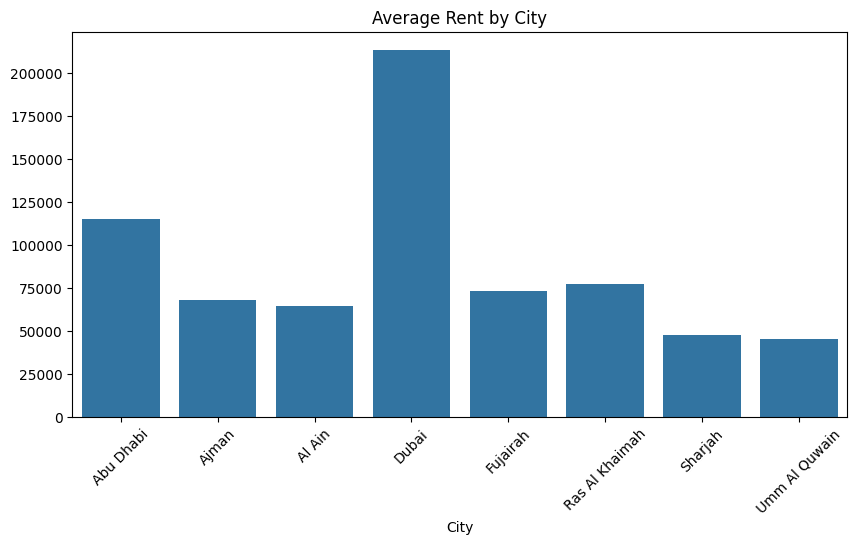

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(x=df.groupby("City")["Rent"].mean().index,
            y=df.groupby("City")["Rent"].mean().values)
plt.xticks(rotation=45)
plt.title("Average Rent by City")
plt.show()

In [23]:
# Does property type affect rent?
df.groupby("Type")["Rent"].mean().sort_values(ascending=False)

,Rent
Type,
Residential Building,2.866282e+06
Residential Floor,1.409327e+06
Penthouse,4.811372e+05
Residential Plot,2.996498e+05
Villa,2.839123e+05
Hotel Apartment,2.257042e+05
Townhouse,1.914537e+05
Villa Compound,1.786589e+05
Apartment,1.096578e+05


Property type has a significant impact on rental prices. Entire residential buildings and floors demand higher rents due to their scale while apartments are affordable and the most common opted listing. Luxury units like penthouses and villas though low in number occupy premium segment of the market.

In [24]:
# Number of listings per property type
df['Type'].value_counts()

,count
Type,
Apartment,56524
Villa,12878
Townhouse,3421
Hotel Apartment,465
Penthouse,270
Villa Compound,107
Residential Building,44
Residential Floor,12
Residential Plot,6


In [25]:
# Correlation between size and rent
df[["Area_in_sqft","Rent"]].corr()

,Area_in_sqft,Rent
Area_in_sqft,1.00000,0.40565
Rent,0.40565,1.00000


Property size shows a moderate positive correlation with rental price (~0.41) indicating that larger properties do command higher rents. However, we can also infer that other factors like location and property type also influence prices.

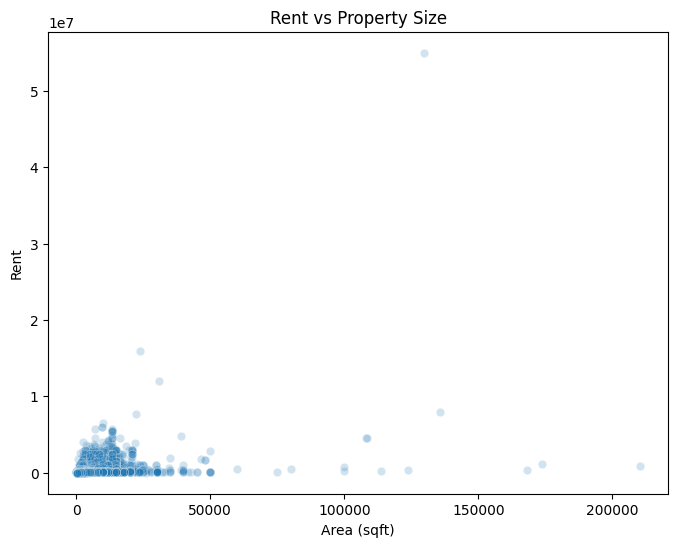

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Area_in_sqft"], y=df["Rent"], alpha=0.2)
plt.title("Rent vs Property Size")
plt.xlabel("Area (sqft)")
plt.ylabel("Rent")
plt.show()

In [27]:
# Does rent per sqft differ across cities?
df.groupby("City")["Rent_per_sqft"].mean().sort_values(ascending=False)

,Rent_per_sqft
City,
Dubai,132.307799
Abu Dhabi,60.303655
Ras Al Khaimah,45.691426
Sharjah,38.403966
Fujairah,30.559652
Umm Al Quwain,28.488834
Ajman,26.539052
Al Ain,26.084755


Even though cities like Sharjah or Ajman may have lower total rent, the rent per sqft metric confirms that Dubai commands a significant premium per unit of space, highlighting its position as the most expensive real-estate market in the UAE dataset.

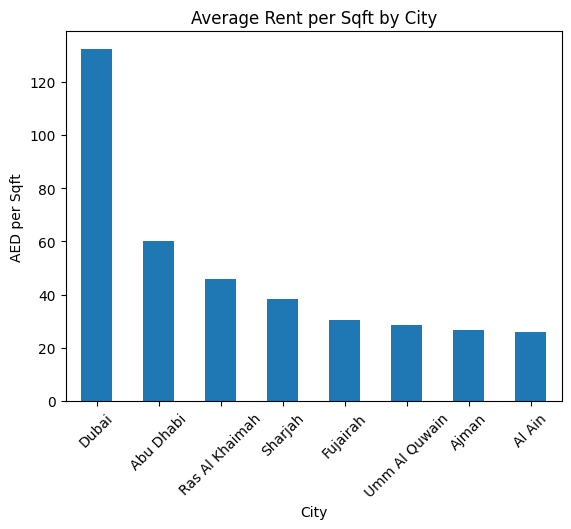

In [28]:
df.groupby("City")["Rent_per_sqft"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Rent per Sqft by City")
plt.ylabel("AED per Sqft")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.show()

In [29]:
# Does number of bedrooms significantly affect rent?
df.groupby("Beds")["Rent"].mean().sort_values()

,Rent
Beds,
0,4.405584e+04
1,8.023706e+04
2,1.285827e+05
3,1.818130e+05
4,2.735896e+05
5,3.030223e+05
9,3.299206e+05
8,3.323088e+05
6,4.224609e+05


Rental price generally increases with bedroom count, confirming that property size and capacity strongly influence rental pricing. However, very large properties (10+ bedrooms) show extreme values due to their rarity and luxury status.

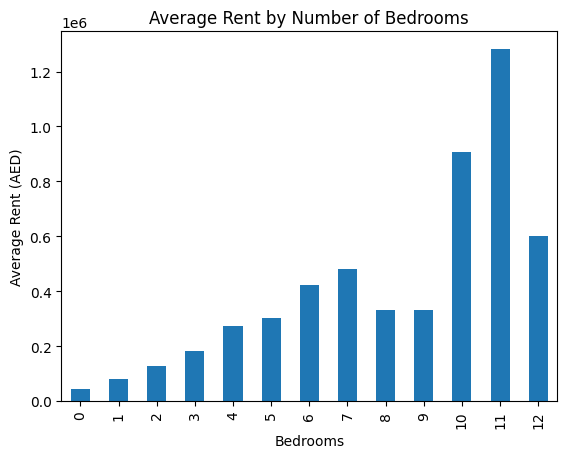

In [30]:
df.groupby("Beds")["Rent"].mean().plot(kind="bar")
plt.title("Average Rent by Number of Bedrooms")
plt.ylabel("Average Rent (AED)")
plt.xlabel("Bedrooms")
plt.show()

- We see a steady rise in average from 0-7 bedroom.
- 8,9,12 bedrooms have a lower average than their predecessor not becuase they're cheaper but because sample size is less in the given dataset.
- 8+ bedrooms reveal outliers and luxury properties than skew averages.

In [31]:
# Which types of properties are most expensive per unit of space?
df.groupby("Type")["Rent_per_sqft"].mean().sort_values(ascending=False)

,Rent_per_sqft
Type,
Hotel Apartment,196.812673
Residential Building,150.178247
Residential Floor,143.966339
Penthouse,115.194195
Apartment,94.237568
Townhouse,83.384975
Villa,57.896039
Villa Compound,46.198270
Residential Plot,21.070414


In the case of the analysis of rent efficiency (AED per sqft), Hotel Apartments and small luxury units lead the way, which shows that high-density premium spaces have the highest price per square foot. Large spaces such as villas and compounds have lower costs per unit despite the high cost of rent due to the distribution of space.

In [32]:
# How does furnishing affect rent?
df.groupby("Furnishing")["Rent"].mean()

,Rent
Furnishing,
Furnished,205708.877392
Unfurnished,132359.358340


Furnished listings call on higher rents (~205k AED vs ~132k AED for unfurnished), indicating a market preference for ready-to-move-in furnished listings.

In [33]:
# Does age of listing affect rent?
df.groupby("Age_of_listing_in_days")["Rent"].mean().head(10)

,Rent
Age_of_listing_in_days,
11,82333.250000
12,100527.914040
13,109750.119658
14,83243.723485
15,116287.215835
16,164713.171784
17,134553.911808
18,171976.889949
19,130509.407437


- No perfectly linear trend
- Some rents are higher for newer listings (16-18 days)

The relation between age of listing and rent is NOT strong at daily level. Aggregating listing age into bigger buckets like months might be better to determine a trend.

In [34]:
# Categorizing into Low, Medium, High buckets
bins = [0, 100000, 300000, df["Rent"].max()]
labels = ["Low", "Medium", "High"]
df["Rent_Category"] = pd.cut(df["Rent"], bins=bins, labels=labels)
df["Rent_Category"].value_counts()

,count
Rent_Category,
Low,38515
Medium,29376
High,5836


Most of the rental market in the UAE is concentrated in low to medium rental properties. We can infer that this means prevalence of standard apartments and family housing. Higher-end properties though few in number, represent the premium segment with a huge impact on average market prices.

In [35]:
# Rent_per_bedroom - Rent_Category
df.groupby("Rent_Category")["Rent_per_bedroom"].mean()

/tmp/ipykernel_698/1005758813.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Rent_Category")["Rent_per_bedroom"].mean()


,Rent_per_bedroom
Rent_Category,
Low,41589.454464
Medium,76949.056330
High,169043.109018


- Rent per bedroom scales proportionally with total price.
- Not just the total rent is high but rent each room is expensive.
- Even though total rent may be affordable, it still provides a functional number of bedrooms.

In [36]:
# Analyzing Rent vs City across different categories
df.groupby(["City", "Rent_Category"]) ["Rent"].count().unstack().fillna(0)

/tmp/ipykernel_698/3703653876.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["City", "Rent_Category"]) ["Rent"].count().unstack().fillna(0)


Rent_Category,Low,Medium,High
City,,,
Abu Dhabi,12983,9789,552
Ajman,3823,842,39
Al Ain,840,200,0
Dubai,11344,17662,5230
Fujairah,19,8,0
Ras Al Khaimah,639,168,9
Sharjah,8809,700,6
Umm Al Quwain,58,7,0


1. Dubai dominates high rent market with 5,230 listings.
2. Dubai(17,662) and Abu Dhabi(9,789) are predominantly visible in the mid-market segment likely includes townhouses, villas and penthouses.
3. Low rent segment - Abu Dhabi(12,983) + Dubai(11,344) + Sharjah(8,809).
4. Smaller emirates have majority low-rent listings, minimal medium and almost no high-rent listings. This is an affordable market.

In [37]:
df.to_csv("dubai_rental_dataset_cleaned.csv", index=False)